## VBE Style Modular Multiplication

- https://arxiv.org/pdf/2306.09122
- https://arxiv.org/pdf/quant-ph/9511018

In [1]:
# !pip install qiskit_aer
%matplotlib inline

import sys
sys.path.append("../src")

from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from mod_adder_vbe import mod_adder_vbe
from mod_mult_vbe import mod_mult_vbe
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math
from qiskit.circuit.library import CDKMRippleCarryAdder

### Modular Adder

In [3]:
n = 4
m = n + 1

N_val = 15

for a_value in range(2**m):
    a_val = a_value
    b_val = 0
    
    a = QuantumRegister(m, 'a') 
    b = QuantumRegister(m, 'b')
    c = QuantumRegister(1, 'c')
    N = QuantumRegister(m, 'N')
    t = QuantumRegister(1, 't')
    
    qc = QuantumCircuit(a, b, c, N, t)  
    
    adder = CDKMRippleCarryAdder(m, kind="fixed").to_gate()
    sub = adder.inverse()

    # set a, b and N
    for i in range(m):
        if (N_val >> i) & 1:
            qc.x(N[i])
        if (a_val >> i) & 1:
            qc.x(a[i])
        if (b_val >> i) & 1:
            qc.x(b[i])
    
    # |a>|b>|c>|N>|t> - > |a>|(a+b) mod 2^m>|c>|N>|t>
    qc.append(adder, a[:] + b[:] + c[:])

    # # |a>|b>|c>|N>|t> - > |N>|(a+b) mod 2^m>|c>|a>|t>
    for i in range(m):
        qc.swap(a[i], N[i])

    # subtract N
    # # |N>|(a+b) mod 2^m>|c>|a>|t> - > |N>|(a+b-N) mod 2^m>|c>|a>|t>
    # s' = s - N = a + b - N
    qc.append(sub, a[:] + b[:] + c[:])

    # determine whether subtraction of N led to an overflow bit in b
    qc.x(b[m-1])
    qc.cx(b[m-1], t[0])
    qc.x(b[m-1])

    # if a + b >= N -> MSB of b = 1, subtraction of N was correct, set a register to 0 which currently temporarily holds N
    # if a + b < N -> MSB of b = 0, subtraction of N was incorrect, set a register to N to add back N
    for i in range(m):
        if (N_val >> i) & 1:
            qc.cx(t[0], a[i])

    # add back N or 0 depending on state of the borrow bit t
    qc.append(adder, a[:] + b[:] + c[:])

    # uncompute
    for i in range(m):
       if (N_val >> i) & 1:
           qc.cx(t[0], a[i]) 

    # swap registers: |N>|a> -> |a>|N>
    for i in range(m):
        qc.swap(a[i], N[i])

    # subtract original a
    qc.append(sub, a[:] + b[:] + c[:])
    
    # uncompute t
    qc.cx(b[m-1], t[0])
    
    # uncompute subtraction
    qc.append(adder, a[:] + b[:] + c[:])

    qc_measure = qc.copy()
    qc_measure.measure_all()
    
    sim = AerSimulator(method="matrix_product_state")
    
    tqc = transpile(qc_measure, sim)
    
    nbr_shots = 2**12
    result = sim.run(tqc, shots=nbr_shots).result()
    counts = result.get_counts()

    # write results
    bitstring = next(iter(counts))  # e.g. "10111100000001111"
    
    t_bits = bitstring[0]
    N_bits = bitstring[1:1+m]
    c_bits = bitstring[1+m]
    b_bits = bitstring[2+m:2+2*m]
    a_bits = bitstring[2+2*m:2+3*m]
    
    print(
        f"t={t_bits} ({int(t_bits,2)}), "
        f"N={N_bits} ({int(N_bits,2)}), "
        f"c={c_bits} ({int(c_bits,2)}), "
        f"b={b_bits} ({int(b_bits,2)}), "
        f"a={a_bits} ({int(a_bits,2)})"
    )

t=0 (0), N=01111 (15), c=0 (0), b=00000 (0), a=00000 (0)
t=0 (0), N=01111 (15), c=0 (0), b=00001 (1), a=00001 (1)
t=0 (0), N=01111 (15), c=0 (0), b=00010 (2), a=00010 (2)
t=0 (0), N=01111 (15), c=0 (0), b=00011 (3), a=00011 (3)
t=0 (0), N=01111 (15), c=0 (0), b=00100 (4), a=00100 (4)
t=0 (0), N=01111 (15), c=0 (0), b=00101 (5), a=00101 (5)
t=0 (0), N=01111 (15), c=0 (0), b=00110 (6), a=00110 (6)
t=0 (0), N=01111 (15), c=0 (0), b=00111 (7), a=00111 (7)
t=0 (0), N=01111 (15), c=0 (0), b=01000 (8), a=01000 (8)
t=0 (0), N=01111 (15), c=0 (0), b=01001 (9), a=01001 (9)
t=0 (0), N=01111 (15), c=0 (0), b=01010 (10), a=01010 (10)
t=0 (0), N=01111 (15), c=0 (0), b=01011 (11), a=01011 (11)
t=0 (0), N=01111 (15), c=0 (0), b=01100 (12), a=01100 (12)
t=0 (0), N=01111 (15), c=0 (0), b=01101 (13), a=01101 (13)
t=0 (0), N=01111 (15), c=0 (0), b=01110 (14), a=01110 (14)
t=0 (0), N=01111 (15), c=0 (0), b=00000 (0), a=01111 (15)
t=0 (0), N=01111 (15), c=0 (0), b=00001 (1), a=10000 (16)
t=0 (0), N=01111 (1

### Modular multiplication

In [5]:
N_val = 15
k_values = range(15)
y_val = 3

results = []
results_calc = []

for k in k_values:
    n = math.ceil(math.log2(N_val + 1))
    m = n + 1
    
    ctrl = QuantumRegister(1, "ctrl")
    a = QuantumRegister(m, 'a') 
    b = QuantumRegister(m, 'b')
    c = QuantumRegister(1, 'c')
    N = QuantumRegister(m, 'N')
    t = QuantumRegister(1, 't')
    y = QuantumRegister(m, 'y')
    creg = ClassicalRegister(m, 'creg')
    
    qc = QuantumCircuit(ctrl, a, b, c, N, t, y, creg)
    
    # load modular adder
    mod_add = mod_adder_vbe(m, N_val) # for overflow we need one additional qubit
    mod_mult = mod_mult_vbe(m, k, N_val, mod_add)

    # prepare N
    for i in range(m):
        if (N_val >> i) & 1:
            qc.x(N[i])
    
    # prepare y
    for i in range(m):
        if (y_val >> i) & 1:
            qc.x(y[i])
    
    # activate control
    qc.x(ctrl[0])
    
    # append adder gate
    qc.append(mod_mult, [ctrl[0]] + a[:] + b[:] + c[:] + N[:] + [t[0]] + y[:])
    
    # measure circuit
    qc_measure = qc.copy()
    qc_measure.measure(y, creg)
    
    sim = AerSimulator(method="matrix_product_state")
    
    tqc = transpile(qc_measure, sim)
    
    nbr_shots = 2**12
    result = sim.run(tqc, shots=nbr_shots).result()
    counts = result.get_counts()

    # write results to list
    for count, prob in counts.items():
        results.append(int(count, 2))

    results_calc.append((y_val * k) % N_val)

In [6]:
results_calc

[0, 3, 6, 9, 12, 0, 3, 6, 9, 12, 0, 3, 6, 9, 12]

In [7]:
results

[0, 3, 6, 9, 12, 0, 3, 6, 9, 12, 0, 3, 6, 9, 12]

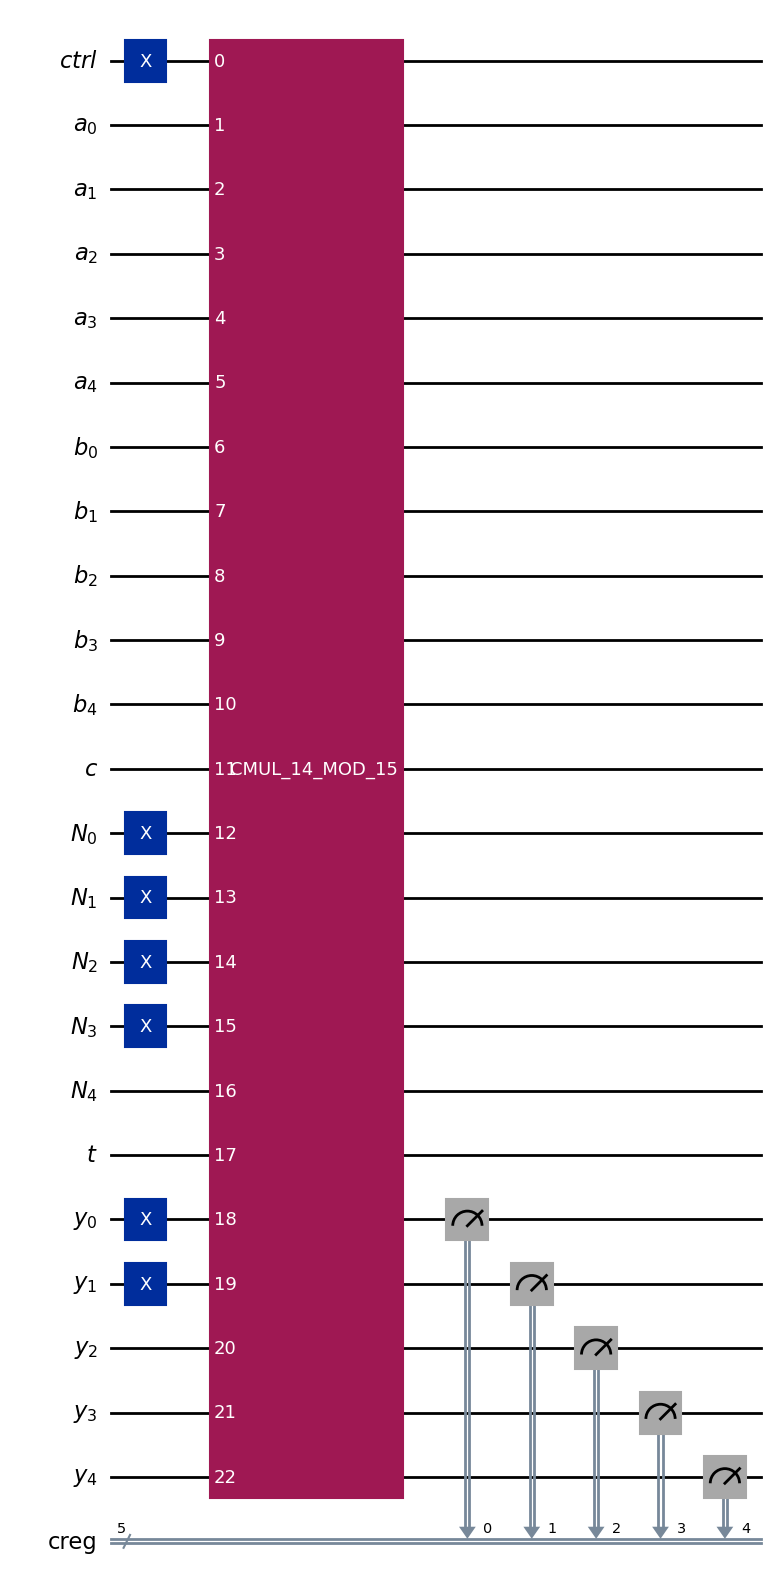

In [8]:
qc_measure.draw('mpl')